# Exploração

**Maj Diego / 2º semestre de 2026**

**Objetivos**

1. Investigar até onde é possível realizar as trasnformações entre sistemas de referência em cima dos dados abertos
2. Join das tabelas LiDAR/Plat/IMU pela coluna tempo
3. Trasnformação para o sistemas de referência da 2ª plataforma giratória (Raster)

## 1. O primeiro segundo do arquivo las exportado pelo software proprietários SLAM GO POST 3.0 

In [3]:
import os
import laspy
from pprint import pprint
import numpy as np
dados_dir = r"..\SN_00007\PROJ1"
las = laspy.read(os.path.join(dados_dir, "result_filtered.laz"))

print("Informações do arquivo LAS:")
pprint(las.header.__dict__)
print("\nQuantidade de pontos:", las.header.point_count)
min_time = 0 
for dim in las.point_format.dimension_names:
    data = las[dim]
    print(f"{dim:20} | Min: {np.min(data):>10} | Max: {np.max(data):>10}")
    if "time" in dim:
        min_time = np.min(data)

new_file = laspy.create(point_format=las.header.point_format, file_version=las.header.version)
new_file.points = las.points[(las.gps_time <= min_time + 1)] ### <-- Filter here

print(f"\nFiltered {len(new_file.points)} points from {min_time} to {min_time+1}")
new_file.write('dados/amostras/extracted_points.las')

for dim in new_file.point_format.dimension_names:
    data = new_file[dim]
    print(f"{dim:20} | Min: {np.min(data):>10} | Max: {np.max(data):>10}")

Informações do arquivo LAS:
{'_point_format': <PointFormat(3, 0 bytes of extra dims)>,
 '_version': Version(major=1, minor=2),
 '_vlrs': [],
 'are_points_compressed': True,
 'creation_date': datetime.date(2026, 9, 21),
 'evlrs': None,
 'extra_header_bytes': b'',
 'extra_vlr_bytes': b'',
 'file_source_id': 0,
 'generating_software': 'LASzip DLL 3.4 r3 (191111)',
 'global_encoding': <laspy.header.GlobalEncoding object at 0x0000021C90113B60>,
 'gps_time_offset': 0,
 'max_gps_time': 0.0,
 'maxs': array([6.498, 6.979, 2.969]),
 'min_gps_time': 0.0,
 'mins': array([-5.778, -5.366, -1.207]),
 'number_of_evlrs': 0,
 'number_of_points_by_return': array([1559033,       0,       0,       0,       0,       0,       0,
             0,       0,       0,       0,       0,       0,       0,
             0], dtype=uint64),
 'offset_to_point_data': 333,
 'offsets': array([0., 0., 0.]),
 'point_count': 1559033,
 'scales': array([0.001, 0.001, 0.001]),
 'start_of_first_evlr': 0,
 'start_of_waveform_data_p

In [4]:
import open3d as o3d
x = np.asarray(new_file.x)
y = np.asarray(new_file.y)
z = np.asarray(new_file.z)
R = np.asarray(new_file.red)/65535
G = np.asarray(new_file.green)/65535
B =np.asarray(new_file.blue)/65535

xyz = np.vstack([x,y,z]).T
RGB = np.vstack([R,G,B]).T
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)
pcd.colors = o3d.utility.Vector3dVector(RGB)
# View in new windows
eixos = o3d.geometry.TriangleMesh.create_coordinate_frame(size=5, origin=[0,0,0])
o3d.visualization.draw_geometries(
    [eixos,pcd],
    window_name="Ground Truth - Pandar View",
    width=1024,
    height=768,
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### 1.1 O segundo correspondente nos dados raw

In [70]:
# Coloque a pasta de dados SN_00007 uma pasta acima do diretório atual:
import os
import struct
import numpy as np
import pandas as pd
from pcapkit import extract

dados_dir = "../SN_00007/PROJ1"
pcap_file = [os.path.join(dados_dir,f) for f in os.listdir(dados_dir) if f.endswith(".pcap")][0]
second_platform_file = [os.path.join(dados_dir,f) for f in os.listdir(dados_dir) if "RASTER" in f.upper()][0]
imu_file = [os.path.join(dados_dir,f) for f in os.listdir(dados_dir) if "_IMU" in f.upper()][0]

# Ler o PCAP com pypcapkit e decodificar os pacotes UDP do Hesai PandarXT-16
# Angulos verticais nominais dos canais 1 a 16 (manual do PandarXT-16).
# Para maior exatidao, substitua-os pelos valores do arquivo de correcao
# angular que acompanha especificamente este sensor.
PANDAR_XT16_RETURN_NAMES = {
    0x33: ("first",),
    0x37: ("strongest",),
    0x38: ("last",),
    0x39: ("last", "strongest"),
    0x3B: ("last", "first"),
    0x3C: ("first", "strongest"),
}

# PANDAR_XT16_ELEVATION_DEG = np.arange(15.0, -16.0, -2.0)
PANDAR_XT16_ELEVATION_DEG = np.array([-15.02000046, -13.        , -10.98999977,  -9.01000023,
                                      -7.        ,  -5.01999998,  -3.03999996,  -1.03999996,
                                       0.94      ,   2.92000008,   4.90999985,   6.88999987,
                                       8.89000034,  10.89000034,  12.90999985,  14.94999981])[::-1]

def segundos_desde_domingo_utc(dt: pd.Timestamp):
    if pd.isna(dt):
        return np.nan
    dt = pd.Timestamp(dt).tz_convert("UTC")
    dias_desde_domingo = (dt.weekday() + 1) % 7
    inicio_domingo = dt.normalize() - pd.Timedelta(dias_desde_domingo, unit="D")
    # Converter apenas a duracao relativa para float; total_seconds() trunca ns.
    return (dt - inicio_domingo).value / 1_000_000_000

def _pandar_xt16_packet_time(payload):
    """Converte os campos UTC do tail do pacote para pandas.Timestamp em UTC."""
    tail_offset = 12 + 8 * 66
    year, month, day, hour, minute, second = payload[tail_offset + 13:tail_offset + 19]
    # https://docs.python.org/3/library/struct.html#struct.calcsize
    # <I = little-endian unsigned int (4 bytes)
    microsecond = struct.unpack_from("<I", payload, tail_offset + 19)[0] # t_ms
    try:
        whole_second = pd.Timestamp(year=1900 + year, month=month, day=day,
                                    hour=hour, minute=minute, second=second, tz="UTC")
        packet_time = whole_second + pd.Timedelta(microsecond * 1_000, unit="ns")
        return packet_time
    except ValueError:
        # O relogio pode ainda nao estar sincronizado no inicio da captura.
        return pd.NaT


def read_pandar_xt16_pcap(path, ini_packet=0, end_packet=None):
    """Extrai pontos PandarXT-16 de um PCAP para um DataFrame.

    ini_packet e end_packet limitam os pacotes LiDAR validos. Use None para ler
    a captura inteira; capturas longas podem consumir muita memoria.
    """
    rows = []
    lidar_packet_count = 0
    ignored_udp_count = 0

    # auto=False e store=False fazem a leitura quadro a quadro, sem guardar
    # uma segunda copia de todo o PCAP na memoria.
    with extract(
        fin=path, auto=False, store=False, nofile=True, engine="default"
    ) as capture:
        for frame in capture:
            if ini_packet is not None and lidar_packet_count < ini_packet:
                lidar_packet_count += 1
                continue

            if "UDP" not in frame:
                continue

            udp = frame["UDP"]
            payload = udp.packet.payload

            # Pre-header 0xEEFF e estrutura fixa do PandarXT-16 v6.1:
            # 6 B pre-header + 6 B header + 8 * 66 B body + 24 B tail + 4 B seq.
            if (
                len(payload) != 568
                or payload[:2] != b"\xee\xff"
                or payload[6] != 16 # Header Channel Num 1 byte Fixed 0x10 (16)
                or payload[7] != 8 # Header Block Num 1 byte Fixed 0x08 (8)
                # or payload[9] != 4 # Header Dis Unit 1 byte Fixed 0x04 (4 mm)
            ):
                ignored_udp_count += 1
                continue
            
            distance_unit_m = payload[9] / 1000.0
            tail_offset = 12 + 8 * 66
            return_mode = payload[tail_offset + 10]
            motor_speed_rpm = struct.unpack_from("<H", payload, tail_offset + 11)[0]
            packet_time = _pandar_xt16_packet_time(payload)
            sequence = struct.unpack_from("<I", payload, tail_offset + 24)[0]
            return_names = PANDAR_XT16_RETURN_NAMES.get(return_mode, (f"0x{return_mode:02X}",))

            for block_index in range(8):
                block_offset = 12 + block_index * 66
                # Os primeiros 2 bytes é o azimute ou ainda
                # ③ Current reference azimuth of this block
                # Como a unidade do azimute é 0,01°, multiplica-se por 0.01
                # <H = little-endian unsigned short int (2 bytes)
                reference_azimuth_deg = struct.unpack_from("<H", payload, block_offset)[0] * 0.01
                return_name = return_names[block_index % len(return_names)]

                for channel_index, elevation_deg in enumerate(PANDAR_XT16_ELEVATION_DEG):
                    channel_offset = block_offset + 2 + channel_index * 4
                    # <H = little-endian unsigned short int (2 bytes)
                    # <B = little-endian unsigned char (1 byte)
                    distance_raw, reflectivity = struct.unpack_from("<HB", payload, channel_offset)
                    if distance_raw == 0: # lixo do sensor, ponto invalido
                        continue

                    # Como a unidade da distância é 0.04 mm,
                    # multiplica-se por 0.00004 pra dar em metros
                    distance_m = distance_raw * distance_unit_m

                    # Analyze the horizontal angle of a data point
                    # https://www.hesaitech.com/wp-content/uploads/2025/08/PandarXT-16_User_Manual_X02-en-250810.pdf#page=59
                    
                    # ⑤ Firing time offset of the current firing channel
                    # B.3: instante do bloco, com deslocamento inteiro em ns.
                    absolute_block_firing_time = packet_time - pd.Timedelta(
                        50_000 * (7 - block_index), unit="ns"
                    )
                    # B.4: 5.632 + 3.024 * channel_index + 0.368 us.
                    firing_time_offset_ns = 6_000 + 3_024 * channel_index
                    firing_time_offset_us = firing_time_offset_ns / 1_000
                    firing_time_offset_s = firing_time_offset_ns / 1_000_000_000
                    absolute_channel_firing_time = absolute_block_firing_time + pd.Timedelta(
                        firing_time_offset_ns, unit="ns"
                    )

                    # ⑥ Spin rate of the motor
                    # See the Motor Speed field in Section 3.1.2.4 Tail. The unit should be converted to °/s
                    # rpm to deg/s: 1 rpm = 6 deg/s
                    motor_speed_deg_per_s = motor_speed_rpm * 6.0
                    
                    # ② Firing time angular offset of the current firing channel
                    # ② = ⑤ × ⑥
                    # https://www.hesaitech.com/wp-content/uploads/2025/08/PandarXT-16_User_Manual_X02-en-250810.pdf#page=96
                    firing_time_angular_offset_deg = firing_time_offset_s * motor_speed_deg_per_s

                    # ④ Horizontal angle offset of the current firing channel
                    # The offset of every channel is 0°, according to Appendix A Channel distribution data.
                    horizontal_offset_deg = 0.0                 
                    
                    # ① Angular position at the start time of the current block
                    # ① = ③ + ④ 
                    angular_position_start_deg = reference_azimuth_deg + horizontal_offset_deg

                    # Horizontal angle = ① + ②
                    # Sempre entre 0 e 360 graus, para evitar problemas de wrap-around.
                    horizontal_angle_deg = ( angular_position_start_deg + 
                                        firing_time_angular_offset_deg ) % 360.0
                    
                    horizontal_angle_rad = np.deg2rad(horizontal_angle_deg)
                    elevation_rad = np.deg2rad(elevation_deg)
                    horizontal_distance = distance_m * np.cos(elevation_rad)

                    # Sistema do fabricante: +Y = azimute 0 graus; +Z para cima.
                    rows.append({
                        "packet": lidar_packet_count,
                        "sequence": sequence,
                        "packet_time_utc": packet_time,
                        "block": block_index + 1,
                        "channel": channel_index + 1,
                        "absolute_block_firing_time": absolute_block_firing_time,
                        "absolute_channel_firing_time": absolute_channel_firing_time,
                        "PACKET_SAMPTIME": segundos_desde_domingo_utc(packet_time), # tempo desde domingo 00:00:00 da semana
                        "BLOCK_SAMPTIME": segundos_desde_domingo_utc(absolute_block_firing_time),
                        "CHANNEL_SAMPTIME": segundos_desde_domingo_utc(absolute_channel_firing_time),
                        "SAMPTIME": segundos_desde_domingo_utc(absolute_channel_firing_time),
                        "return": return_name,
                        "azimuth_deg": reference_azimuth_deg,
                        "elevation_deg": elevation_deg,
                        "distance_m": distance_m,
                        "reflectivity": reflectivity,
                        "firing_time_offset_us": firing_time_offset_us,
                        "firing_time_angular_offset_deg": firing_time_angular_offset_deg,
                        "horizontal_angle_deg": horizontal_angle_deg,
                        "x": horizontal_distance * np.sin(horizontal_angle_rad),
                        "y": horizontal_distance * np.cos(horizontal_angle_rad),
                        "z": distance_m * np.sin(elevation_rad),
                    })

            lidar_packet_count += 1
            if end_packet is not None and lidar_packet_count >= end_packet:
                break

    points = pd.DataFrame.from_records(rows)
    print(
        f"{lidar_packet_count} pacotes LiDAR, {len(points)} pontos validos "
        f"e {ignored_udp_count} pacotes UDP ignorados."
    )
    return points

# Le uma amostra controlada. Troque por end_packet=None para a captura inteira. 304021.78125 + 1
lidar_points = read_pandar_xt16_pcap(pcap_file, ini_packet=11_300, end_packet=13_200)
pd.set_option("display.precision", 9)
pd.set_option("display.max_columns", None)
lidar_points.loc[lidar_points["channel"]==16]

13200 pacotes LiDAR, 237528 pontos validos e 1 pacotes UDP ignorados.


,packet,sequence,packet_time_utc,block,channel,absolute_block_firing_time,absolute_channel_firing_time,PACKET_SAMPTIME,BLOCK_SAMPTIME,CHANNEL_SAMPTIME,SAMPTIME,return,azimuth_deg,elevation_deg,distance_m,reflectivity,firing_time_offset_us,firing_time_angular_offset_deg,horizontal_angle_deg,x,y,z
15,11300,230733,2024-10-23 12:27:01.773353+00:00,1,16,2024-10-23 12:27:01.773003+00:00,2024-10-23 12:27:01.773054360+00:00,304021.773353,304021.773003,304021.77305436,304021.77305436,strongest,323.51,-15.02000046,0.368,4,51.36,0.18458784,323.69458784,-0.210444783,0.286429145,-0.095369485
31,11300,230733,2024-10-23 12:27:01.773353+00:00,2,16,2024-10-23 12:27:01.773053+00:00,2024-10-23 12:27:01.773104360+00:00,304021.773353,304021.773053,304021.77310436,304021.77310436,strongest,323.69,-15.02000046,0.368,4,51.36,0.18458784,323.87458784,-0.209543902,0.287088862,-0.095369485
47,11300,230733,2024-10-23 12:27:01.773353+00:00,3,16,2024-10-23 12:27:01.773103+00:00,2024-10-23 12:27:01.773154360+00:00,304021.773353,304021.773103,304021.77315436,304021.77315436,strongest,323.87,-15.02000046,0.364,4,51.36,0.18458784,324.05458784,-0.206373117,0.284618074,-0.094332860
63,11300,230733,2024-10-23 12:27:01.773353+00:00,4,16,2024-10-23 12:27:01.773153+00:00,2024-10-23 12:27:01.773204360+00:00,304021.773353,304021.773153,304021.77320436,304021.77320436,strongest,324.05,-15.02000046,0.372,4,51.36,0.18458784,324.23458784,-0.209993944,0.291534570,-0.096406110
79,11300,230733,2024-10-23 12:27:01.773353+00:00,5,16,2024-10-23 12:27:01.773203+00:00,2024-10-23 12:27:01.773254360+00:00,304021.773353,304021.773203,304021.77325436,304021.77325436,strongest,324.23,-15.02000046,0.376,4,51.36,0.18458784,324.41458784,-0.211325167,0.295334704,-0.097442735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237471,13199,232632,2024-10-23 12:27:02.806722+00:00,4,16,2024-10-23 12:27:02.806522+00:00,2024-10-23 12:27:02.806573360+00:00,304022.806722,304022.806522,304022.80657336,304022.80657336,strongest,84.18,-15.02000046,0.340,4,51.36,0.18489600,84.36489600,0.326797103,0.032244895,-0.088113111
237485,13199,232632,2024-10-23 12:27:02.806722+00:00,5,16,2024-10-23 12:27:02.806572+00:00,2024-10-23 12:27:02.806623360+00:00,304022.806722,304022.806572,304022.80662336,304022.80662336,strongest,84.36,-15.02000046,0.336,4,51.36,0.18489600,84.54489600,0.323050946,0.030850803,-0.087076486
237499,13199,232632,2024-10-23 12:27:02.806722+00:00,6,16,2024-10-23 12:27:02.806622+00:00,2024-10-23 12:27:02.806673360+00:00,304022.806722,304022.806622,304022.80667336,304022.80667336,strongest,84.54,-15.02000046,0.340,4,51.36,0.18489600,84.72489600,0.326993251,0.030190946,-0.088113111
237513,13199,232632,2024-10-23 12:27:02.806722+00:00,7,16,2024-10-23 12:27:02.806672+00:00,2024-10-23 12:27:02.806723360+00:00,304022.806722,304022.806672,304022.80672336,304022.80672336,strongest,84.72,-15.02000046,0.348,4,51.36,0.18489600,84.90489600,0.334782638,0.029849719,-0.090186361


In [71]:
lidar_points_2 = lidar_points[(lidar_points["SAMPTIME"]>=min_time) & (lidar_points["SAMPTIME"]<=min_time+1)].copy()
print(f"\nFiltered {len(lidar_points_2)} points from {lidar_points_2.SAMPTIME.min()} to {lidar_points_2.SAMPTIME.max()}")


Filtered 234964 points from 304021.804615 to 304022.77926836


### 1.2 Os dados da 2ª plataforma giratória

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_closest_row(df, target, column="SAMPTIME"):
    closest_rows = df.iloc[(df[column] - target).abs().argsort()[:2]]
    return closest_rows

def interpolar_angulos_raster(df, tempos, angle_column="ANGLE"):
    serie = (df[["SAMPTIME", angle_column]].apply(pd.to_numeric, errors="coerce")
             .dropna().sort_values("SAMPTIME").drop_duplicates("SAMPTIME", keep="last"))
    if len(serie) < 2:
        raise ValueError("Sao necessarias pelo menos duas amostras RASTER.")
    angulos = np.unwrap(np.deg2rad(serie[angle_column].to_numpy()))
    interpolados = np.interp(tempos, serie["SAMPTIME"].to_numpy(), angulos,
                            left=np.nan, right=np.nan)
    return np.rad2deg(interpolados) % 360.0

def get_precise_angle_given_time(df, desired_time, angle_column="ANGLE"):
    return float(interpolar_angulos_raster(df, desired_time, angle_column))

raster_columns = ["SAMPTIME", "DIR", "INC", "ANGLE", "NUM"]
raster_data = pd.read_csv(
    second_platform_file,
    skiprows=1, names=raster_columns
)
raster_data = raster_data.apply(pd.to_numeric, errors="coerce").dropna()
raster_data = raster_data[(raster_data["SAMPTIME"]>=min_time) & (raster_data["SAMPTIME"]<=min_time+1)]
raster_data

,SAMPTIME,DIR,INC,ANGLE,NUM
6292,304021.781932,0,372,65.390625,55
6293,304021.782813,0,373,65.566406,55
6294,304021.783712,0,374,65.742188,55
6295,304021.784634,0,375,65.917969,55
6296,304021.785547,0,376,66.093750,55
...,...,...,...,...,...
7317,304022.776806,0,1397,245.566406,55
7318,304022.777716,0,1398,245.742188,55
7319,304022.778645,0,1399,245.917969,55
7320,304022.779561,0,1400,246.093750,55


In [73]:
### 1.2

## 2. Join das tabelas pelo timestamp

In [74]:
display(lidar_points_2[["packet_time_utc", "SAMPTIME", "reflectivity", "x", "y", "z"]].head())
display(raster_data.head())


,packet_time_utc,SAMPTIME,reflectivity,x,y,z
1982,2024-10-23 12:27:01.804959+00:00,304021.804615000,19,4.396085098,0.989768284,1.203200130
1983,2024-10-23 12:27:01.804959+00:00,304021.804618024,16,0.570575410,0.128350008,0.134052143
1984,2024-10-23 12:27:01.804959+00:00,304021.804621048,19,0.555693440,0.124891596,0.109575956
1985,2024-10-23 12:27:01.804959+00:00,304021.804624072,18,0.555253896,0.124682169,0.089013864
1986,2024-10-23 12:27:01.804959+00:00,304021.804627096,18,0.538596493,0.120834440,0.066699743


,SAMPTIME,DIR,INC,ANGLE,NUM
6292,304021.781932,0,372,65.390625,55
6293,304021.782813,0,373,65.566406,55
6294,304021.783712,0,374,65.742188,55
6295,304021.784634,0,375,65.917969,55
6296,304021.785547,0,376,66.093750,55


### 2.1 Verificar que a coleta de tempos na 2º plataforma giratória e do IMU começaram mais cedo

In [75]:
# lidar_points["RASTER_ANGLE_INTERPOLATED"] = lidar_points["SAMPTIME"].apply(
#     lambda x: get_precise_angle_given_time(raster_data, desired_time=x)
# )
# # 11m 34s

# for i, row in lidar_points.iterrows():
#     lidar_points.at[i, "RASTER_ANGLE_INTERPOLATED"] = get_precise_angle_given_time(raster_data, desired_time=row["SAMPTIME"])
# # # 11m 50s
# lidar_points[["packet_time_utc", "SAMPTIME", "reflectivity", "x", "y", "z"]]

In [76]:
# AJUSTE MANUAL: tempo somado ao SAMPTIME para consultar o angulo RASTER.
# Positivo consulta um instante posterior; negativo, um anterior. Unidade: segundos.
# Exemplo: 0.010 = 10 ms. O SAMPTIME original permanece preservado.
# Ao alterar, reexecute desta celula ate o desenho de pcd2 (draw_plotly).
OFFSET_RASTER_S = 0.0

# Interpolacao vetorizada, sem reutilizar resultados da formula anterior.
# SAMPTIME ja representa o disparo do canal, calculado na secao 6.5.
# A igualdade da escala de tempo entre sensores ainda depende da sincronizacao fisica.
lidar_points_2["RASTER_ANGLE_INTERPOLATED"] = interpolar_angulos_raster(
    raster_data, lidar_points_2["SAMPTIME"].to_numpy() + OFFSET_RASTER_S
)
print("Pontos fora da cobertura RASTER:", lidar_points_2["RASTER_ANGLE_INTERPOLATED"].isna().sum())
lidar_points_2[["SAMPTIME", "RASTER_ANGLE_INTERPOLATED"]].head()


Pontos fora da cobertura RASTER: 0


,SAMPTIME,RASTER_ANGLE_INTERPOLATED
1982,304021.804615000,69.769624413
1983,304021.804618024,69.770176973
1984,304021.804621048,69.770729533
1985,304021.804624072,69.771282093
1986,304021.804627096,69.771834653


In [165]:
# Sincronizar cada ponto LiDAR com as amostras temporalmente mais próximas
# do RASTER e da IMU. Igualdade exata não é adequada porque os sensores
# possuem frequências de aquisição diferentes.
imu_columns = [
    "SAMPTIME", "ACCX", "ACCY", "ACCZ",
    "GYRX", "GYRY", "GYRZ", "Q0", "Q1", "Q2", "Q3"
]
imu_data = pd.read_csv(
    imu_file,
    skiprows=1, names=imu_columns
)
imu_data = imu_data.apply(pd.to_numeric, errors="coerce").dropna()

def preparar_serie_temporal(data, prefixo):
    serie = data.copy()
    serie["SAMPTIME"] = pd.to_numeric(serie["SAMPTIME"], errors="coerce")
    serie = (
        serie.dropna(subset=["SAMPTIME"])
        .sort_values("SAMPTIME")
        .drop_duplicates(subset=["SAMPTIME"], keep="last")
    )

    # Preservar o timestamp de origem permite auditar a sincronização.
    renomear = {
        coluna: (
            f"{prefixo}_SAMPTIME"
            if coluna == "SAMPTIME"
            else f"{prefixo}_{coluna}"
        )
        for coluna in serie.columns
    }
    return serie.rename(columns=renomear)


def tolerancia_sincronizacao(data):
    # Três períodos medianos acomodam pequeno jitter, mas evitam associar
    # registros separados por uma lacuna longa na aquisição.
    intervalos = (
        data["SAMPTIME"].sort_values().drop_duplicates().diff().dropna()
    )
    intervalos = intervalos[intervalos > 0]
    if intervalos.empty:
        raise ValueError("Não há timestamps suficientes para estimar a tolerância.")
    return 3.0 * intervalos.median()


lidar_temporal = lidar_points_2.copy()
lidar_temporal["SAMPTIME"] = pd.to_numeric(
    lidar_temporal["SAMPTIME"], errors="coerce"
)
lidar_temporal = (
    lidar_temporal.dropna(subset=["SAMPTIME"])
    .sort_values("SAMPTIME")
    .reset_index(drop=True)
)

raster_temporal = preparar_serie_temporal(raster_data, "RASTER")
imu_temporal = preparar_serie_temporal(imu_data, "IMU")
raster_tolerance_s = tolerancia_sincronizacao(raster_data)
imu_tolerance_s = tolerancia_sincronizacao(imu_data)

dados_sincronizados = pd.merge_asof(
    lidar_temporal,
    raster_temporal,
    left_on="SAMPTIME",
    right_on="RASTER_SAMPTIME",
    direction="nearest",
    tolerance=raster_tolerance_s,
)
dados_sincronizados = pd.merge_asof(
    dados_sincronizados,
    imu_temporal,
    left_on="SAMPTIME",
    right_on="IMU_SAMPTIME",
    direction="nearest",
    tolerance=imu_tolerance_s,
)

dados_sincronizados["RASTER_TIME_ERROR_S"] = (
    dados_sincronizados["SAMPTIME"]
    - dados_sincronizados["RASTER_SAMPTIME"]
).abs()
dados_sincronizados["IMU_TIME_ERROR_S"] = (
    dados_sincronizados["SAMPTIME"]
    - dados_sincronizados["IMU_SAMPTIME"]
).abs()

taxa_raster = dados_sincronizados["RASTER_SAMPTIME"].notna().mean()
taxa_imu = dados_sincronizados["IMU_SAMPTIME"].notna().mean()
print(f"Pontos sincronizados: {len(dados_sincronizados):,}")
print(f"Correspondência RASTER: {taxa_raster:.2%} | IMU: {taxa_imu:.2%}")
pd.set_option('display.max_columns', None)

primeiro_pacote = dados_sincronizados["packet"].min()
dados_sincronizados = dados_sincronizados[ (dados_sincronizados["packet"] > primeiro_pacote+150) & (dados_sincronizados["packet"] <= primeiro_pacote+650)]
display(dados_sincronizados.head())

Pontos sincronizados: 234,964
Correspondência RASTER: 100.00% | IMU: 100.00%


,packet,sequence,packet_time_utc,block,channel,absolute_block_firing_time,absolute_channel_firing_time,PACKET_SAMPTIME,BLOCK_SAMPTIME,CHANNEL_SAMPTIME,SAMPTIME,return,azimuth_deg,elevation_deg,distance_m,reflectivity,firing_time_offset_us,firing_time_angular_offset_deg,horizontal_angle_deg,x,y,z,RASTER_ANGLE_INTERPOLATED,RASTER_SAMPTIME,RASTER_DIR,RASTER_INC,RASTER_ANGLE,RASTER_NUM,IMU_SAMPTIME,IMU_ACCX,IMU_ACCY,IMU_ACCZ,IMU_GYRX,IMU_GYRY,IMU_GYRZ,IMU_Q0,IMU_Q1,IMU_Q2,IMU_Q3,RASTER_TIME_ERROR_S,IMU_TIME_ERROR_S
19146,11467,230900,2024-10-23 12:27:01.865368+00:00,1,1,2024-10-23 12:27:01.865018+00:00,2024-10-23 12:27:01.865024+00:00,304021.865368,304021.865018,304021.865024000,304021.865024000,strongest,294.79,14.94999981,0.620,6,6.000,0.0216000,294.8116000,-0.543720374,0.251367680,0.159945129,79.768285384,304021.865246,0,454,79.804688,55,304021.865015,-1.326255,0.704946,9.563374,0.001596,0.007982,-0.013303,0.996864,0.002419,0.053707,0.000409,0.000222000,0.000009000
19147,11467,230900,2024-10-23 12:27:01.865368+00:00,1,2,2024-10-23 12:27:01.865018+00:00,2024-10-23 12:27:01.865027024+00:00,304021.865368,304021.865018,304021.865027024,304021.865027024,strongest,294.79,12.90999985,0.616,5,9.024,0.0324864,294.8224864,-0.544956935,0.252065040,0.137626867,79.768781248,304021.865246,0,454,79.804688,55,304021.865015,-1.326255,0.704946,9.563374,0.001596,0.007982,-0.013303,0.996864,0.002419,0.053707,0.000409,0.000218976,0.000012024
19148,11467,230900,2024-10-23 12:27:01.865368+00:00,1,3,2024-10-23 12:27:01.865018+00:00,2024-10-23 12:27:01.865030048+00:00,304021.865368,304021.865018,304021.865030048,304021.865030048,strongest,294.79,10.89000034,0.608,5,12.048,0.0433728,294.8333728,-0.541843448,0.250749913,0.114865830,79.769277111,304021.865246,0,454,79.804688,55,304021.865015,-1.326255,0.704946,9.563374,0.001596,0.007982,-0.013303,0.996864,0.002419,0.053707,0.000409,0.000215952,0.000015048
19149,11467,230900,2024-10-23 12:27:01.865368+00:00,1,4,2024-10-23 12:27:01.865018+00:00,2024-10-23 12:27:01.865033072+00:00,304021.865368,304021.865018,304021.865033072,304021.865033072,strongest,294.79,8.89000034,0.600,4,15.072,0.0542592,294.8442592,-0.537931095,0.249063495,0.092722775,79.769772975,304021.865246,0,454,79.804688,55,304021.865015,-1.326255,0.704946,9.563374,0.001596,0.007982,-0.013303,0.996864,0.002419,0.053707,0.000409,0.000212928,0.000018072
19150,11467,230900,2024-10-23 12:27:01.865368+00:00,1,5,2024-10-23 12:27:01.865018+00:00,2024-10-23 12:27:01.865036096+00:00,304021.865368,304021.865018,304021.865036096,304021.865036096,strongest,294.79,6.88999987,0.592,5,18.096,0.0651456,294.8551456,-0.533285774,0.247035758,0.071018431,79.770268838,304021.865246,0,454,79.804688,55,304021.865015,-1.326255,0.704946,9.563374,0.001596,0.007982,-0.013303,0.996864,0.002419,0.053707,0.000409,0.000209904,0.000021096


## 3. Transformação dos pontos LiDAR para a 2º Plat Giratória (RASTER)

In [170]:
from scipy.spatial.transform import Rotation

# q = [0.01498514, -0.00045287, -0.00149213, 0.99988653]
q = [0.99988653 , 0.01498514, -0.00045287, -0.00149213]

R_raster_para_lidar = Rotation.from_quat(np.array(q, dtype=float)).as_matrix()

# Equivalente a Ry(-angulo) @ R_raster_para_lidar @ p
######## Obsoleto, lento: ##########
# def Ry(pitch):
#    pitch = np.deg2rad(pitch)
#    return np.array([[np.cos(pitch), 0, np.sin(pitch)],
#                     [0            , 1,      0        ],
#                     [-np.sin(pitch), 0, np.cos(pitch) ]])
# def Rx(roll):
#     roll = np.deg2rad(roll)
#     return np.array([[1,        0      ,      0     ],
#                      [0, np.cos(roll) , -np.sin(roll)],
#                      [0, np.sin(roll), np.cos(roll)]])
# def Rz(yaw):
#     yaw = np.deg2rad(yaw)
#     return np.array([[np.cos(yaw) ,-np.sin(yaw), 0],
#                      [np.sin(yaw),np.cos(yaw), 0],
#                      [0             ,0        , 1]])
# for i, row in dados_sincronizados.iterrows():
#     xyz_RASTER = Ry(-row["RASTER_ANGLE_INTERPOLATED"]) @ R_raster_para_lidar @ np.array([row["x"], row["y"], row["z"]])
#     dados_sincronizados.at[i, "x_RASTER"] = xyz_RASTER[0]
#     dados_sincronizados.at[i, "y_RASTER"] = xyz_RASTER[1]
#     dados_sincronizados.at[i, "z_RASTER"] = xyz_RASTER[2]

######## Rápido e generalista: ##########
rotation_axis = "y"
invert_rotation = False
angle_offset_deg = 0.0

xyz_lidar = dados_sincronizados[["x", "y", "z"]].to_numpy(dtype=float).T
px, py, pz = R_raster_para_lidar @ xyz_lidar
if invert_rotation:
    rot = -1 * dados_sincronizados["RASTER_ANGLE_INTERPOLATED"].to_numpy(dtype=float) - angle_offset_deg
else:
    rot = dados_sincronizados["RASTER_ANGLE_INTERPOLATED"].to_numpy(dtype=float) - angle_offset_deg
angulo_rad = np.deg2rad(rot)
cos_a = np.cos(angulo_rad)
sin_a = np.sin(angulo_rad)

# Aplicar Ry por componente evita criar uma matriz 3x3 por ponto.
xyz_RASTER = np.empty_like(xyz_lidar.T)

if rotation_axis == 'x':
    rx = px
    ry = py * cos_a - pz * sin_a
    rz = py * sin_a + pz * cos_a
elif rotation_axis == 'y':
    rx = px * cos_a + pz * sin_a
    ry = py
    rz = -px * sin_a + pz * cos_a
else:
    rx = px * cos_a - py * sin_a
    ry = px * sin_a + py * cos_a
    rz = pz

xyz_RASTER[:, 0] = rx
xyz_RASTER[:, 1] = ry
xyz_RASTER[:, 2] = rz
dados_sincronizados[["x_RASTER", "y_RASTER", "z_RASTER"]] = xyz_RASTER
# dados_sincronizados.to_csv("dados/amostras/dados_sincronizados.csv", index=False)
dados_sincronizados


,packet,sequence,packet_time_utc,block,channel,absolute_block_firing_time,absolute_channel_firing_time,PACKET_SAMPTIME,BLOCK_SAMPTIME,CHANNEL_SAMPTIME,SAMPTIME,return,azimuth_deg,elevation_deg,distance_m,reflectivity,firing_time_offset_us,firing_time_angular_offset_deg,horizontal_angle_deg,x,y,z,RASTER_ANGLE_INTERPOLATED,RASTER_SAMPTIME,RASTER_DIR,RASTER_INC,RASTER_ANGLE,RASTER_NUM,IMU_SAMPTIME,IMU_ACCX,IMU_ACCY,IMU_ACCZ,IMU_GYRX,IMU_GYRY,IMU_GYRZ,IMU_Q0,IMU_Q1,IMU_Q2,IMU_Q3,RASTER_TIME_ERROR_S,IMU_TIME_ERROR_S,x_RASTER,y_RASTER,z_RASTER
19146,11467,230900,2024-10-23 12:27:01.865368+00:00,1,1,2024-10-23 12:27:01.865018+00:00,2024-10-23 12:27:01.865024+00:00,304021.865368,304021.865018,304021.865024000,304021.865024000,strongest,294.79,14.94999981,0.620,6,6.000,0.0216000,294.8116000,-0.543720374,0.251367680,0.159945129,79.768285384,304021.865246,0,454,79.804688,55,304021.865015,-1.326255,0.704946,9.563374,0.001596,0.007982,-0.013303,0.996864,0.002419,0.053707,0.000409,0.000222000,0.000009000,-0.252908050,-0.267072913,0.499108783
19147,11467,230900,2024-10-23 12:27:01.865368+00:00,1,2,2024-10-23 12:27:01.865018+00:00,2024-10-23 12:27:01.865027024+00:00,304021.865368,304021.865018,304021.865027024,304021.865027024,strongest,294.79,12.90999985,0.616,5,9.024,0.0324864,294.8224864,-0.544956935,0.252065040,0.137626867,79.768781248,304021.865246,0,454,79.804688,55,304021.865015,-1.326255,0.704946,9.563374,0.001596,0.007982,-0.013303,0.996864,0.002419,0.053707,0.000409,0.000218976,0.000012024,-0.231153529,-0.267873308,0.504249875
19148,11467,230900,2024-10-23 12:27:01.865368+00:00,1,3,2024-10-23 12:27:01.865018+00:00,2024-10-23 12:27:01.865030048+00:00,304021.865368,304021.865018,304021.865030048,304021.865030048,strongest,294.79,10.89000034,0.608,5,12.048,0.0433728,294.8333728,-0.541843448,0.250749913,0.114865830,79.769277111,304021.865246,0,454,79.804688,55,304021.865015,-1.326255,0.704946,9.563374,0.001596,0.007982,-0.013303,0.996864,0.002419,0.053707,0.000409,0.000215952,0.000015048,-0.208199297,-0.266533080,0.505249612
19149,11467,230900,2024-10-23 12:27:01.865368+00:00,1,4,2024-10-23 12:27:01.865018+00:00,2024-10-23 12:27:01.865033072+00:00,304021.865368,304021.865018,304021.865033072,304021.865033072,strongest,294.79,8.89000034,0.600,4,15.072,0.0542592,294.8442592,-0.537931095,0.249063495,0.092722775,79.769772975,304021.865246,0,454,79.804688,55,304021.865015,-1.326255,0.704946,9.563374,0.001596,0.007982,-0.013303,0.996864,0.002419,0.053707,0.000409,0.000212928,0.000018072,-0.185713045,-0.264795952,0.505364985
19150,11467,230900,2024-10-23 12:27:01.865368+00:00,1,5,2024-10-23 12:27:01.865018+00:00,2024-10-23 12:27:01.865036096+00:00,304021.865368,304021.865018,304021.865036096,304021.865036096,strongest,294.79,6.88999987,0.592,5,18.096,0.0651456,294.8551456,-0.533285774,0.247035758,0.071018431,79.770268838,304021.865246,0,454,79.804688,55,304021.865015,-1.326255,0.704946,9.563374,0.001596,0.007982,-0.013303,0.996864,0.002419,0.053707,0.000409,0.000209904,0.000021096,-0.163529918,-0.262694392,0.504691611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80895,11966,231399,2024-10-23 12:27:02.139813+00:00,8,12,2024-10-23 12:27:02.139813+00:00,2024-10-23 12:27:02.139852264+00:00,304022.139813,304022.139813,304022.139852264,304022.139852264,strongest,204.37,-7.00000000,3.320,33,39.264,0.1413504,204.5113504,-1.367113237,-2.998282042,-0.404606220,129.484542587,304022.140211,0,737,129.550781,55,304022.140015,-0.886560,-0.174444,9.491684,0.003193,0.005321,-0.005321,0.996821,0.002166,0.054512,0.000411,0.000358736,0.000162736,1.245917638,2.954750352,0.859964880
80896,11966,231399,2024-10-23 12:27:02.139813+00:00,8,13,2024-10-23 12:27:02.139813+00:00,2024-10-23 12:27:02.139855288+00:00,304022.139813,304022.139813,304022.139855288,304022.139855288,strongest,204.37,-9.01000023,3.276,33,42.288,0.1522368,204.5222368

In [171]:
# Colorir por pacote: inteiros indexam a paleta; floats em [0, 1] percorrem suas cores.
xyz = dados_sincronizados[["x_RASTER","y_RASTER","z_RASTER"]].to_numpy(dtype=float, copy=True)
# xyz = dados_sincronizados[["x","y","z"]].to_numpy(dtype=float, copy=True)


packet = dados_sincronizados["packet"].to_numpy(dtype=int)
packet_normalizado = np.zeros(packet.shape, dtype=float)
if packet.size:
    packet_min = packet.min()
    packet_span = packet.max() - packet_min
    if packet_span > 0:
        packet_normalizado = (packet - packet_min) / packet_span
packet_colors = plt.get_cmap("viridis")(packet_normalizado)[:, :3]
# OR:
channels = dados_sincronizados[["channel"]].to_numpy(dtype=int, copy=True)
channel_colors = plt.get_cmap("tab20")(channels.reshape(-1) - 1)[:,:3]

pcd2 = o3d.geometry.PointCloud()
pcd2.points = o3d.utility.Vector3dVector(xyz)  
pcd2.colors = o3d.utility.Vector3dVector(channel_colors)
# View in cell below
# Eixos XYZ = RGB:
eixos = o3d.geometry.TriangleMesh.create_coordinate_frame(size=4, origin=[0,0,0])
o3d.visualization.draw_geometries(
    [eixos,pcd2],
    window_name="Ground Truth - Pandar View",
    width=1024,
    height=768,
)

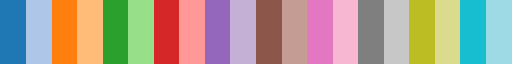

In [100]:
plt.get_cmap("tab20")

In [132]:
# Execute antes a celula de transformacao. Backend interativo: pip install ipympl.
# Documentacao: https://matplotlib.org/ipympl/examples/full-example.html
get_ipython().run_line_magic("matplotlib", "widget")

import asyncio
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from scipy.spatial.transform import Rotation


class AppQuaternionRaster:
    def __init__(self, dados, quaternion, angulos_rad,
                 eixo_rotacao="y", max_pontos=8000):
        self.dados = dados
        self.montados = dados[["x", "y", "z"]].to_numpy(dtype=float)
        self.angulos = np.asarray(angulos_rad, dtype=float).copy()
        if self.angulos.shape != (len(dados),):
            raise ValueError("Reexecute a transformacao para alinhar os angulos aos pontos.")
        self.eixo_inicial = eixo_rotacao
        self.par_eixos = {"x": (1, 2), "y": (2, 0), "z": (0, 1)}[eixo_rotacao]
        self.cos = np.cos(self.angulos)
        self.sin = np.sin(self.angulos)
        self.q_inicial = Rotation.from_quat(quaternion).as_quat()
        self.quaternion = self.q_inicial.copy()
        self._pendente = None
        self._pausado = False

        validos = np.flatnonzero(np.isfinite(self.montados).all(axis=1)
                                & np.isfinite(self.angulos))
        if not len(validos):
            raise ValueError("Nao ha pontos validos para visualizar.")
        if max_pontos < 1:
            raise ValueError("max_pontos deve ser maior que zero.")
        # Amostra fixa e distribuida pela captura: a nuvem nao muda ao arrastar.
        self.indices = validos[np.linspace(0, len(validos) - 1,
                                           min(max_pontos, len(validos)), dtype=int)]
        packet = dados["packet"].to_numpy(dtype=float)
        norm = plt.Normalize(vmin=packet[validos].min(), vmax=packet[validos].max())

        with plt.ioff():
            self.fig = plt.figure(figsize=(8, 6), layout="constrained")
        self.ax = self.fig.add_subplot(111, projection="3d")
        pontos = self.transformar(self.quaternion, self.indices)
        self.scatter = self.ax.scatter(*pontos.T, c=packet[self.indices],
                                       cmap="viridis", norm=norm, s=2,
                                       alpha=0.85, linewidths=0, depthshade=False)
        self.fig.colorbar(self.scatter, ax=self.ax, shrink=0.65, pad=0.08,
                          label="Pacote LiDAR")
        # Rotacoes preservam a norma: limites fixos evitam saltos e cortes.
        raio = max(float(np.linalg.norm(self.montados[self.indices], axis=1).max()), 1.0) * 1.05
        self.ax.set(xlim=(-raio, raio), ylim=(-raio, raio), zlim=(-raio, raio),
                    xlabel="X RASTER (m)", ylabel="Y RASTER (m)", zlabel="Z RASTER (m)",
                    title="Ajuste do quaternion LiDAR / RASTER")
        self.ax.set_box_aspect((1, 1, 1))
        self.ax.view_init(elev=22, azim=-60)
        self.limites_iniciais = (-raio, raio)
        self.ax.mouse_init(rotate_btn=1, pan_btn=2, zoom_btn=3)
        self.fig.canvas.header_visible = False
        self.fig.canvas.toolbar_position = "bottom"

        self.sliders = [widgets.FloatSlider(
            value=float(value), min=-1.0, max=1.0, step=0.00001,
            description=name, readout_format=".6f", continuous_update=True,
            style={"description_width": "35px"}, layout=widgets.Layout(width="98%")
        ) for name, value in zip(("qx", "qy", "qz", "qw"), self.q_inicial)]
        self.seletor_eixo = widgets.ToggleButtons(
            options=[("X", "x"), ("Y", "y"), ("Z", "z")], value=eixo_rotacao,
            description="Eixo RASTER",
            style={"description_width": "100px", "button_width": "55px"})
        self.seletor_eixo.observe(self.mudar_eixo, names="value")
        self._sincronizando_camera = False
        self.camera_azim = widgets.FloatSlider(
            value=-60, min=-180, max=180, step=1, description="Azimute",
            continuous_update=True, layout=widgets.Layout(width="98%"))
        self.camera_elev = widgets.FloatSlider(
            value=22, min=-180, max=180, step=1, description="Elevacao",
            continuous_update=True, layout=widgets.Layout(width="98%"))
        for controle in (self.camera_azim, self.camera_elev):
            controle.observe(self.mover_camera, names="value")
        self._evento_camera = self.fig.canvas.mpl_connect(
            "button_release_event", self.sincronizar_camera)
        self.botao_orbita = widgets.Button(description="Orbitar com mouse", icon="arrows")
        self.botao_vista = widgets.Button(description="Restaurar vista", icon="home")
        self.botao_orbita.on_click(self.ativar_orbita)
        self.botao_vista.on_click(self.restaurar_vista)
        controles_camera = widgets.Accordion(
            children=[widgets.VBox([self.camera_azim, self.camera_elev])],
            selected_index=None)
        controles_camera.set_title(0, "Camera: azimute e elevacao (graus)")
        self.valor_q = widgets.HTML()
        self.mensagem = widgets.HTML()
        self.botao_reset = widgets.Button(description="Restaurar inicial", icon="undo")
        self.botao_aplicar = widgets.Button(description="Aplicar a todos os pontos",
                                            button_style="primary", icon="check",
                                            layout=widgets.Layout(width="220px"))
        self.botao_reset.on_click(self.restaurar)
        self.botao_aplicar.on_click(self.aplicar)
        for slider in self.sliders:
            slider.observe(self.agendar, names="value")
        self.botao_aplicar.layout.width = "100%"
        self.botao_reset.layout.width = "100%"
        self.painel_parametros = widgets.VBox([
            widgets.HTML("<b>Quaternion [x, y, z, w]</b> — arraste os sliders ou edite os valores."),
            *self.sliders, self.seletor_eixo, self.valor_q,
            self.botao_aplicar, self.botao_reset, self.mensagem,
            widgets.HBox([self.botao_orbita, self.botao_vista],
                         layout=widgets.Layout(flex_flow="row wrap")),
            widgets.HTML("Na cena: arraste com o botao esquerdo para orbitar, "
                         "direito para zoom e central para deslocar. "
                         "Clique em Orbitar com mouse para sair dos modos Pan/Zoom da barra."),
            controles_camera,
        ], layout=widgets.Layout(width="340px", min_width="340px", padding="8px",
                                  align_items="stretch"))
        self.fig.canvas.layout.width = "100%"
        self.painel_visualizacao = widgets.VBox([
            widgets.HTML(f"Previa: {len(self.indices):,} de {len(validos):,} pontos validos. "
                         f"{len(dados) - len(validos):,} pontos sem coordenadas/angulos validos omitidos. "
                         "Cores por pacote."),
            self.fig.canvas,
        ], layout=widgets.Layout(width="100%", min_width="620px"))
        # Duas colunas; em janelas estreitas, a saida permite rolagem horizontal.
        self.ui = widgets.GridBox(
            [self.painel_parametros, self.painel_visualizacao],
            layout=widgets.Layout(width="100%", grid_template_columns="340px minmax(620px, 1fr)",
                                  grid_gap="16px", align_items="flex-start", overflow="auto"),
        )
        self.atualizar()

    def transformar(self, quaternion, indices=None):
        indices = slice(None) if indices is None else indices
        pontos = self.montados[indices] @ Rotation.from_quat(quaternion).as_matrix().T
        resultado = pontos.copy()
        a, b = self.par_eixos
        cos, sin = self.cos[indices], self.sin[indices]
        resultado[:, a] = cos * pontos[:, a] - sin * pontos[:, b]
        resultado[:, b] = sin * pontos[:, a] + cos * pontos[:, b]
        return resultado

    def mudar_eixo(self, change):
        self.par_eixos = {"x": (1, 2), "y": (2, 0), "z": (0, 1)}[change["new"]]
        self.agendar(change)

    def ativar_orbita(self, _=None):
        toolbar = self.fig.canvas.toolbar
        modo = self.ax.get_navigate_mode()
        if modo == "PAN":
            toolbar.pan()
        elif modo == "ZOOM":
            toolbar.zoom()
        self.ax.mouse_init(rotate_btn=1, pan_btn=2, zoom_btn=3)

    def mover_camera(self, change):
        if self._sincronizando_camera:
            return
        self.ax.view_init(elev=self.camera_elev.value, azim=self.camera_azim.value,
                          roll=self.ax.roll)
        self.fig.canvas.draw_idle()

    def sincronizar_camera(self, event=None):
        # Refletir a orbita com o mouse sem disparar uma nova rotacao da vista.
        self._sincronizando_camera = True
        try:
            self.camera_azim.value = (self.ax.azim + 180) % 360 - 180
            self.camera_elev.value = (self.ax.elev + 180) % 360 - 180
        finally:
            self._sincronizando_camera = False

    def restaurar_vista(self, _=None):
        self.ativar_orbita()
        self.ax.view_init(elev=22, azim=-60, roll=0)
        self.ax.set(xlim=self.limites_iniciais, ylim=self.limites_iniciais,
                    zlim=self.limites_iniciais)
        self.sincronizar_camera()
        self.fig.canvas.draw_idle()

    def agendar(self, change):
        if self._pausado:
            return
        # Agrupar eventos durante o arraste sem enfileirar renders antigos.
        try:
            loop = asyncio.get_running_loop()
        except RuntimeError:
            self.atualizar()
        else:
            if self._pendente is None:
                self._pendente = loop.call_later(0.05, self.atualizar)

    def atualizar(self):
        if self._pendente is not None:
            self._pendente.cancel()
            self._pendente = None
        valores = np.array([slider.value for slider in self.sliders])
        norma = np.linalg.norm(valores)
        if norma < 1e-12:
            self.botao_aplicar.disabled = True
            self.mensagem.value = "Quaternion nulo: ajuste pelo menos um componente."
            return False
        self.botao_aplicar.disabled = False
        self.quaternion = valores / norma
        pontos = self.transformar(self.quaternion, self.indices)
        self.scatter.set_offsets(pontos[:, :2])
        self.scatter.set_3d_properties(pontos[:, 2], zdir="z")
        texto_q = ", ".join(f"{value:.9f}" for value in self.quaternion)
        self.valor_q.value = (f"Quaternion normalizado: <code>q = [{texto_q}]</code><br>"
                              f"<code>rotation_axis = '{self.seletor_eixo.value}'</code>")
        self.mensagem.value = "Previa atualizada. Clique em Aplicar para atualizar a nuvem inteira."
        self.fig.canvas.draw_idle()
        return True

    def restaurar(self, _=None):
        self._pausado = True
        for slider, value in zip(self.sliders, self.q_inicial):
            slider.value = float(value)
        self.seletor_eixo.value = self.eixo_inicial
        self._pausado = False
        self.atualizar()

    def aplicar(self, _=None):
        global q, R_raster_para_lidar, xyz_RASTER, xyz, rotation_axis
        if not self.atualizar():
            return
        resultado = self.transformar(self.quaternion)
        self.dados[["x_RASTER", "y_RASTER", "z_RASTER"]] = resultado
        q = self.quaternion.tolist()
        rotation_axis = self.seletor_eixo.value
        R_raster_para_lidar = Rotation.from_quat(q).as_matrix()
        xyz_RASTER = resultado
        xyz = resultado
        self.mensagem.value = (f"Quaternion e eixo {rotation_axis.upper()} aplicados aos {len(self.dados):,} pontos. "
                               "Copie q e rotation_axis acima para a celula de transformacao para salvar o ajuste no codigo.")

    def close(self):
        if self._pendente is not None:
            self._pendente.cancel()
        for slider in self.sliders:
            slider.unobserve(self.agendar, names="value")
            slider.close()
        self.seletor_eixo.unobserve(self.mudar_eixo, names="value")
        self.seletor_eixo.close()
        for controle in (self.camera_azim, self.camera_elev):
            controle.unobserve(self.mover_camera, names="value")
            controle.close()
        self.fig.canvas.mpl_disconnect(self._evento_camera)
        self.botao_orbita.close()
        self.botao_vista.close()
        self.botao_reset.close()
        self.botao_aplicar.close()
        self.painel_parametros.close()
        self.painel_visualizacao.close()
        self.ui.close()
        plt.close(self.fig)


# Reutiliza exatamente a montagem e os angulos calculados na celula anterior.
# Reexecute essa celula se alterar mount_axes ou os offsets.
if "app_quaternion" in globals():
    app_quaternion.close()
MAX_PONTOS_PREVIA = 8000
app_quaternion = AppQuaternionRaster(
    dados_sincronizados, q, angulo_rad,
    eixo_rotacao=rotation_axis, max_pontos=MAX_PONTOS_PREVIA,
)
display(app_quaternion.ui)


GridBox(children=(VBox(children=(HTML(value='<b>Quaternion [x, y, z, w]</b> — arraste os sliders ou edite os v…

In [ ]:
# ## save
 
# from pathlib import Path

# import laspy

# def lidar_points_to_las(points, output_path, x_column="x", y_column="y", z_column="z"):
#     """Exporta o DataFrame de pontos para LAS 1.4 (coordenadas em metros)."""

#     output_path = Path(output_path)
#     output_path.parent.mkdir(parents=True, exist_ok=True)

#     header = laspy.LasHeader(point_format=6, version="1.4")
#     header.scales = np.array([0.001, 0.001, 0.001])  # precisao de 1 mm
#     header.offsets = points[[x_column, y_column, z_column]].min().to_numpy(dtype=float)

#     extra_dimensions = {
#         "packet": np.uint32,
#         "sequence": np.uint32,
#         "block": np.uint8,
#         "channel": np.uint8,
#         "azimuth_deg": np.float32,
#         "elevation_deg": np.float32,
#         "distance_m": np.float32,
#     }
#     for name, dtype in extra_dimensions.items():
#         if name in points:
#             header.add_extra_dim(laspy.ExtraBytesParams(name=name, type=dtype))

#     if "packet_time_utc" in points:
#         header.add_extra_dim(
#             laspy.ExtraBytesParams(name="unix_time_utc", type=np.float64)
#         )

#     las = laspy.LasData(header)
#     las.x = points[x_column].to_numpy(dtype=float)
#     las.y = points[y_column].to_numpy(dtype=float)
#     las.z = points[z_column].to_numpy(dtype=float)
#     reflectivity = points["reflectivity"].clip(0, 255).to_numpy(dtype=np.uint16)
#     las.intensity = reflectivity * np.uint16(257)  # 0..255 -> 0..65535

#     for name, dtype in extra_dimensions.items():
#         if name in points:
#             las[name] = points[name].to_numpy(dtype=dtype)

#     if "packet_time_utc" in points:
#         packet_time = pd.to_datetime(points["packet_time_utc"], utc=True)
#         unix_time_utc = np.full(len(packet_time), np.nan, dtype=np.float64)
#         has_time = packet_time.notna().to_numpy()
#         unix_time_utc[has_time] = (
#             packet_time[has_time].astype("int64").to_numpy() / 1e9
#         )
#         las["unix_time_utc"] = unix_time_utc

#     las.write(output_path)
#     print(f"{len(points):,} pontos exportados para {output_path.resolve()}")
#     return output_path

# # lidar_las_path = lidar_points_to_las(dados_sincronizados, "dados/amostras/lidar_points.las", x_column="x", y_column="y", z_column="z")
# pcl_las_path = lidar_points_to_las(dados_sincronizados, "dados/amostras/pcl_points_y.las", x_column="x_RASTER", y_column="y_RASTER", z_column="z_RASTER")